In [1]:
import pathlib
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pingouin as pg
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities_ES as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig3_sparseKO_place_fields')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
import pickle 
with open('/home/mplitt/shuffle_pkls/sparse_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [4]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for mouse in sparse_mice:
    for day in range(6):
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
               
                rising_edges = shuff_results[mouse][chan][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][chan][day][nov]['falling_edges']
                widths = shuff_results[mouse][chan][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25)  #* (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
              

                n_fields = np.bincount(rising_edges[mask,0])
                
        
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)
        

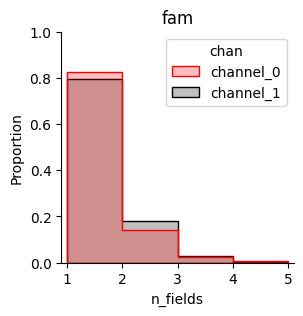

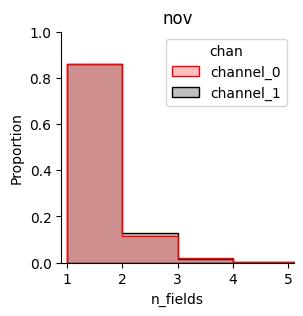

In [5]:
for nov in ('fam', 'nov'):

    fig,ax = plt.subplots(figsize=[3,3])
    sns.histplot(data=df.loc[df['nov']==nov,:], x='n_fields', hue='chan', cumulative=False, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
                binwidth=1., fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    ax.set_ylim([0,1])
    ax.set_xlim([.9,5.1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    fig.savefig(figdir / f'n_fields_hist_{nov}.pdf', bbox_inches='tight')



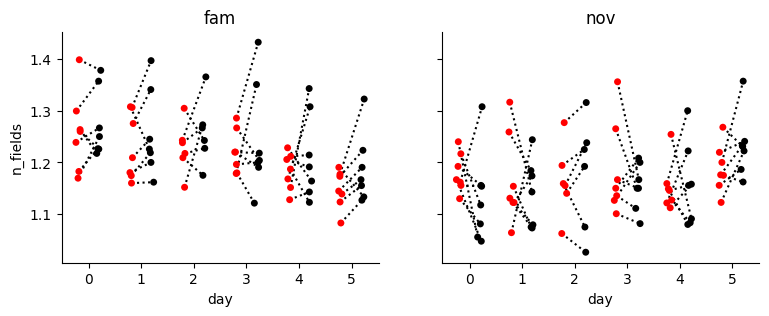

In [6]:
df_mu = df.groupby(['mouse','day','chan','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='n_fields',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)
    ax[i].set_title(nov)



    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    
fig.savefig( figdir / 'n_fields_per_day.pdf', bbox_inches='tight')

In [ ]:
df['cre'] = df["cre"].astype("category")
    df["mouse"] = df["mouse"].astype("category")
    df["day"] = df["day"].astype("category")
    df["nov"] = df["nov"].astype("category")
    df["rank_width"] = df["width"].rank()


In [ ]:
# Permute genotype within each mouse if within-mouse design
    df_perm["genotype"] = df_perm.groupby("mouse")["genotype"].transform(np.random.permutation)
    

In [132]:
res_fam = pg.pairwise_tests(data=df.loc[df['nov']=='fam',:],
                        dv='n_fields',
                        within=[ 'chan', 'day'],
                        subject='mouse',
                        padjust='holm',
                        parametric=False, marginal=False)

res_nov = pg.pairwise_tests(data=df.loc[df['nov']=='nov',:],
                        dv='n_fields',
                        within=[ 'chan', 'day' ],
                        subject='mouse',
                        padjust='holm',
                        parametric=False, marginal=False)

In [133]:
res_fam.iloc[0]

Contrast            chan
chan                   -
A              channel_0
B              channel_1
Paired              True
Parametric         False
W-val                2.0
alternative    two-sided
p-unc            0.09375
p-corr               NaN
p-adjust             NaN
hedges         -0.588399
Name: 0, dtype: object

In [134]:
res_nov.iloc[0]

Contrast            chan
chan                   -
A              channel_0
B              channel_1
Paired              True
Parametric         False
W-val                9.0
alternative    two-sided
p-unc            0.84375
p-corr               NaN
p-adjust             NaN
hedges          0.078848
Name: 0, dtype: object

## permutation test

In [178]:
def run_perm_test(df, stat_column, n_perms=1000):
    rng = np.random.default_rng()
    perm_res = {'fam': [], 'nov': []}
    
    mice = df['mouse'].unique().tolist()
    df_perm = df.copy()
    df_perm['chan_copy'] = df_perm['chan'].copy()

    for p in range(n_perms):
        for nov in ('fam', 'nov'):
            for mouse in mice:
                for day in range(6):
                    mask = (df_perm['mouse']==mouse) & (df_perm['nov']==nov) & (df_perm['day']==day)
                    df_perm.loc[(df_perm['mouse']==mouse) & (df_perm['nov']==nov) & (df_perm['day']==day),'chan_copy'] = rng.permutation(df_perm.loc[mask,'chan']) #.copy().sample(frac=1).values
           
            perm_res[nov].append(pg.pairwise_tests(data=df_perm.loc[df_perm['nov']==nov,:],
                                                dv=stat_column,
                                                within=[ 'chan_copy', 'day'],
                                                subject='mouse',
                                                parametric=False, effsize='AUC').iloc[0]['AUC'])

    return perm_res


In [179]:
perm_res = run_perm_test(df, 'n_fields')

In [180]:
perm_res['fam']

[np.float64(0.5396854377096274),
 np.float64(0.5347695347068839),
 np.float64(0.5702752392132558),
 np.float64(0.5525938052085282),
 np.float64(0.4076194005539162),
 np.float64(0.3965550878516404),
 np.float64(0.47095075923858815),
 np.float64(0.3884672041281244),
 np.float64(0.5326868611559565),
 np.float64(0.5078626813745287),
 np.float64(0.37439395054171576),
 np.float64(0.5640822160400168),
 np.float64(0.6446044779920508),
 np.float64(0.5145170782988202),
 np.float64(0.5116028570199612),
 np.float64(0.6080185077576262),
 np.float64(0.5910101866704666),
 np.float64(0.4468301459314515),
 np.float64(0.4270937936477114),
 np.float64(0.5035385609205931),
 np.float64(0.38961491818329486),
 np.float64(0.5683978181519221),
 np.float64(0.5994732271961906),
 np.float64(0.3875065084630442),
 np.float64(0.5176380780393606),
 np.float64(0.5897139387927477),
 np.float64(0.458794963570172),
 np.float64(0.4337690033362324),
 np.float64(0.46246308299830374),
 np.float64(0.5052576616131829),
 np.flo

In [181]:
for nov in ('fam', 'nov'):
    auc = pg.pairwise_tests(data=df.loc[df['nov']==nov,:],
                                    dv='n_fields',
                                    within=[ 'chan', 'day'],
                                    subject='mouse',
                                    parametric=False, effsize='AUC').iloc[0]['AUC']
    p = np.sum(np.array(perm_res[nov])<=auc)/len(perm_res[nov])
    print(f'{nov}: AUC={auc}, p={p}')
# u_sum = 0
    # for mouse in sparse_mice:
    #     for day in range(6):
    #         sub_df = df.loc[(df['mouse']==mouse) & (df['nov']==nov) & (df['day']==day),:]
    #         # sub_df = df.loc[(df['mouse']==mouse) & (df['nov']==nov) ,:]
    #         if sub_df.shape[0]==0:
    #             continue

    #         x = sub_df.loc[sub_df['chan']=='channel_1','n_fields']
    #         y = sub_df.loc[sub_df['chan']=='channel_0','n_fields']
    #         u = sp.stats.mannwhitneyu(
    #             x,y,
    #             alternative='two-sided').statistic
    #         u_sum += u/x.shape[0]/y.shape[0]
    
    # p = np.sum(np.array(perm_res[nov])<=u_sum/len(sparse_mice)/6)/len(perm_res[nov])
    # print(f'{nov}: U={u_sum/len(sparse_mice)/6}, p={p}')

fam: AUC=0.3260911457479352, p=0.032
nov: AUC=0.5240814269668018, p=0.588


In [188]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'width': []}
for mouse in sparse_mice:
    for day in range(6):
        
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
                rising_edges = shuff_results[mouse][chan][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][chan][day][nov]['falling_edges']
                widths = shuff_results[mouse][chan][day][nov]['field_widths']
                
                mask = (widths>1) * (widths<25) * (rising_edges[:,1]>0) * (falling_edges[:,1]<29)
                widths = widths[mask]

                for w in widths:
                   
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['width'].append(10*w)

df = pd.DataFrame.from_dict(df)

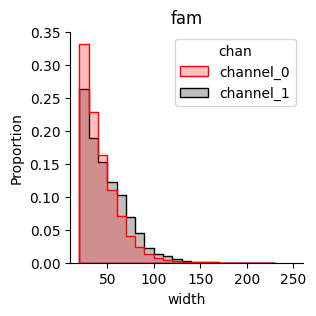

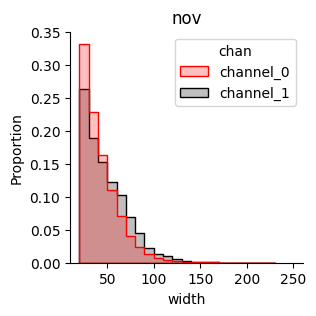

In [189]:


for nov in ('fam', 'nov'):
    fig,ax = plt.subplots(figsize=[3,3])

    sns.histplot(data=df, 
                 x='width', 
                 hue='chan', 
                 cumulative=False, 
                 hue_order=('channel_0', 'channel_1'), 
                 palette=['red', 'black'],
                 binwidth=10, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
    
    ax.set_xlim([10,260])
    ax.set_ylim([0,.35])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(nov)

    fig.savefig(figdir / f'field_widths_hist_{nov}.pdf', bbox_inches='tight')


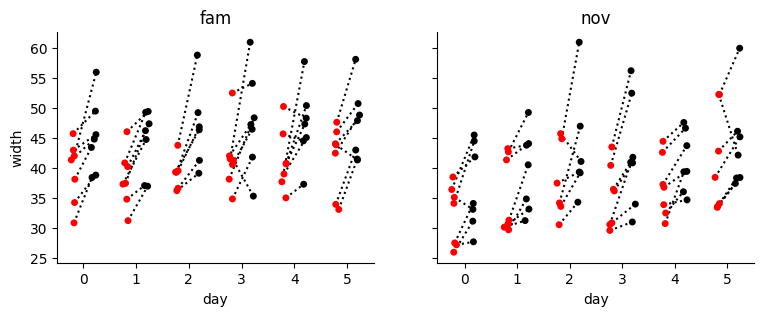

In [190]:
df_mu = df.groupby(['mouse','day','chan','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey=True)
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='width',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=.2,
                ax=ax[i],
                legend=False)
    ax[i].set_title(nov)


    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig( figdir / 'field_widths_per_day.pdf', bbox_inches='tight')

In [191]:


res_fam = pg.pairwise_tests(data=df.loc[df['nov']=='fam', :],
                        dv='width',
                        within=[ 'chan', 'day'],
                        subject='mouse',
                        padjust='holm',
                        parametric=False, marginal=False)

res_nov = pg.pairwise_tests(data=df.loc[df['nov']=='nov', :],
                        dv='width',
                        within=[ 'chan', 'day'],
                        subject='mouse',
                        padjust='holm',
                        parametric=False, marginal=False)

In [192]:
res_fam.iloc[0]

Contrast            chan
chan                   -
A              channel_0
B              channel_1
Paired              True
Parametric         False
W-val                0.0
alternative    two-sided
p-unc            0.03125
p-corr               NaN
p-adjust             NaN
hedges         -1.091254
Name: 0, dtype: object

In [193]:
res_nov.iloc[0]

Contrast            chan
chan                   -
A              channel_0
B              channel_1
Paired              True
Parametric         False
W-val                0.0
alternative    two-sided
p-unc            0.03125
p-corr               NaN
p-adjust             NaN
hedges         -0.787973
Name: 0, dtype: object

In [80]:
perm_res = run_perm_test(df, 'width')

In [ ]:
for nov in ('fam', 'nov'):
    auc = pg.pairwise_tests(data=df.loc[df['nov']==nov,:],
                                    dv='width',
                                    within=[ 'chan', 'day'],
                                    subject='mouse',
                                    parametric=False, effsize='AUC').iloc[0]['AUC']
    p = np.sum(np.array(perm_res[nov])<=auc)/len(perm_res[nov])
    print(f'{nov}: AUC={auc}, p={p}')

fam: U=0.5674767051925633, p=0.0
nov: U=0.5519950725350787, p=0.0
